In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import time
from pathlib import Path
from scipy.stats import mstats

pd.set_option('display.max_columns', 500) 
# pd.set_option('display.max_colwidth', None)

# print multiple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# data pre-processing

In [3]:
path = Path.joinpath(Path.cwd().parent / '1 Data', "010223_capiq.xlsx")
df_raw = pd.read_excel(path, sheet_name = "Sheet1")

df_raw.head()
df_raw.shape

,quarter_guided,quarter_previous,date_guided,date_previous,actuals_announcement_date,guidance_annoucement_date,firm_id,isin,actual_revenue,revenue_guidance_average,revenue_guidance_range,analyst_mean_guidance_date,sic,fama_french_industry,revenue_prev,revenue_prev2,revenue_prev3,ebit,ebitda,gross_profit,earnings_cont_operations,net_income,restructuring_charges,cogs,rd,sga,selling_marketing,depreciation_amortization,assets,cash_eq,inventory_turnover,receivables,liabilities,warranty_liablities,total_debt,total_equity,nwc,change_nwc,capex,free_cash_flow,cash_from_invest,cash_from_finance,cash_from_oper,bankruptcy_score,marketcap,price_at_guidance,price_15days,price_40days,price_60days,price_180days,price_vola_3month,price_vola_6month,beta_russell_60days,short_interest_at_guidance,short_interest_15,short_interest_60,short_interest_180,short_sales_score,total_dividends,goodwill,goodwill_impairment,restricted_cash,restricted_cash_total,gain_on_sale_assets,gain_on_sale_invest,operating_income,warranty_liabilities,asset_writedown,inventory,raw_materials_inventory,work_in_progress_inventory,finished_goods_inventory,change_in_inventories,book_value_share,real_gdp_growth,ebit_margin,ebitda_margin,net_income_margin,roic_an,return_on_equity,cash_asset_ratio,nwc_assets,capex_assets_ratio
0,FQ22010,FQ12010,2010-06-30,2010-03-31,2010-04-29 00:00:00,2010-05-17 00:00:00,6,US78463M1071,10.944,10.50,0.2,NaN,7370,36,10.243,9.981,9.634,1.047,1.387,7.262,0.919,0.919,0.0,2.981,1.043,5.172,3.507,0.340,22.940,5.996,0.0,5.125,16.658,0.0,2.632,6.282,2.472,1.093,-0.130,-0.20575,-0.130,-0.059,0.254,-1.24916,0.00000,6.47,6.75,0.000,0,0,0,0,0.61713,0.00488,0,0,0,1,0.0,1.166,0.0,0.0,0.0,0.0,0.0,1.047,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-90.94105,2.79432,29.7577,32.8667,22.7254,26.1176,58.5312,0.067580,-0.075353,-0.006908
1,FQ32010,FQ22010,2010-09-30,2010-06-30,2010-07-29 00:00:00,2010-07-29 00:00:00,6,US78463M1071,11.491,11.20,0.2,10.93175,7370,36,10.944,10.243,9.981,0.679,1.084,7.843,0.638,0.638,0.0,3.101,1.067,6.097,4.122,0.405,54.652,37.973,0.0,4.987,14.057,0.0,0.343,40.595,1.449,-1.023,-1.084,0.93525,-1.084,30.613,2.448,6.32578,134.85631,5.50,5.89,5.810,6.04,0,0,0,0.41101,2.00408,2.04147,0.25658,0,1,0.0,1.166,0.0,0.0,0.0,0.0,0.0,0.679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.74865,2.56376,32.5017,35.9535,24.1611,39.7240,61.3908,0.074374,-0.072445,-0.012284
2,FQ42010,FQ32010,2010-12-31,2010-09-30,2010-10-28 00:00:00,2010-10-28 00:00:00,6,US78463M1071,11.919,11.80,0.2,11.63200,7370,36,11.491,10.944,10.243,0.868,1.271,8.280,0.886,0.886,0.0,3.211,1.108,6.304,4.139,0.403,56.227,39.113,0.0,5.517,14.507,0.0,0.122,41.720,1.617,0.168,-0.016,0.98850,-0.016,-0.214,1.370,5.42021,148.80857,6.50,6.78,6.410,5.11,6.75,43.5066,0,-1.43538,2.11958,2.16905,1.88298,0,1,0.0,1.166,0.0,0.0,0.0,0.0,0.0,0.868,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.79399,1.87468,31.8576,35.7510,24.1999,32.8400,59.3192,0.056904,-0.097077,-0.012316
3,FQ12011,FQ42010,2011-03-31,2010-12-31,2011-02-09 00:00:00,2011-02-09 00:00:00,6,US78463M1071,12.649,12.20,0.2,12.12467,7370,36,11.919,11.491,10.944,0.442,0.827,8.586,0.441,0.441,0.0,3.333,1.131,7.013,4.833,0.385,57.880,40.473,0.0,5.574,14.372,0.0,0.122,43.508,2.201,0.584,-0.542,-0.17675,-0.542,1.055,0.847,6.94382,187.11534,8.50,8,7.900,7.315,4.65,37.3196,42.1121,0.6264,1.27983,2.24239,2.60826,1.97486,1,0.0,1.166,0.0,0.0,0.0,0.0,0.0,0.442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.83585,2.00418,29.8132,33.6256,22.8344,27.1120,54.9140,0.049438,-0.081878,-0.010068
4,FQ22011,FQ12011,2011-06-30,2011-03-31,2011-04-28 00:00:00,2011-05-18 00:00:00,6,US78463M1071,13.937,13.25,0.3,12.82429,7370,36,12.649,11.919,11.491,0.507,0.929,9.328,0.492,0.492,0.0,3.321,1.240,7.581,5.126,0.422,59.317,40.447,0.0,6.356,14.980,0.0,0.000,44.337,3.043,0.842,-0.488,-0.27913,-0.488,-0.098,0.560,7.73489,184.25396,8.45,8.88,7.755,6.89,6.575,46.0775,36.7757,1.23295,1.47515,1.34352,1.42219,2.13473,1,0.0,1.166,0.0,0.0,0.0,0.0,0.0,0.507,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.86577,2.31258,27.6906,31.7174,23.6804,28.8772,70.9740,0.119799,-

(27149, 83)

In [104]:
df = df_raw.copy()

# remove rows containing "(Invalid Date)"
df = df[~df.isin(['(Invalid Date)']).any(axis=1)]

# create observation count per firm
df["firm_observations"] = df.groupby(["isin"])["isin"].transform('size')
df.insert(df.columns.get_loc("isin")+1, "firm_observations", df.pop("firm_observations"))

# assign id to each firm
df["firm_id"] = df.groupby(["isin"]).ngroup() + 1
df.insert(df.columns.get_loc("isin")+1, "firm_id", df.pop("firm_id"))

# set datetime objects
df["actuals_announcement_date"] = pd.to_datetime(df["actuals_announcement_date"].astype(str).str[:11])
df["guidance_annoucement_date"] = pd.to_datetime(df["guidance_annoucement_date"].astype(str).str[:11])
df['quarter_guided'], df['quarter_previous'] = pd.PeriodIndex(df["date_guided"], freq='Q'), pd.PeriodIndex(df["date_previous"], freq='Q') # from fiscal to calendar quarter

# sort
df = df.sort_values(by=["firm_id", "quarter_guided"], ascending=[1,1]).reset_index(drop=True)

df = df[(df["actual_revenue"] > 0)] # filter negative actual_revenue
# drop irrelevant cols
df = df.drop(columns=["earnings_cont_operations", "restricted_cash_total", "short_sales_score", "bankruptcy_score"], axis=1)

# remove columns containing NA (substitute for NaN)
# for col in df.columns[df.isin(['NA']).any()].to_list():
#     df = df.drop(columns=[col], axis=1)

# replace NA with 0 (only affects less relevant features)
df = df.replace({"NA": 0})

## create categorical vars
# create upper sic categories
# "Use range as a key value in a dictionary, most efficient way?"
limits = [999, 1499, 1799, 1999, 3999, 4999, 5199, 5999, 6799, 8999, 9729, 9999]
values = ["Agriculture, Forestry and Fishing", "Mining", "Construction", "not used", "Manufacturing", "Transportation, Communications, Electric, Gas and Sanitary service", "Wholesale Trade", "Retail Trade", "Finance, Insurance and Real Estate", "Services", "Public Administration", "Nonclassifiable"]
import bisect
def value_at(n):
    index = bisect.bisect_left(limits, n)
    return values[index]

df["sic_division"] = df["sic"].map(lambda x: value_at(x))
df["sic_division"] = pd.Categorical(df["sic_division"]).codes
df["sic_division"] = df["sic_division"].astype("int64")
df.insert(df.columns.get_loc("sic")+1, "sic_division", df.pop("sic_division"))

# create and move categorical int columns
categorical_features = df.drop(columns=["firm_observations"], axis=1).select_dtypes(include=[int]).columns.to_list()
for index, cat_col in enumerate(categorical_features, start=1):
    df.insert(df.columns.get_loc("firm_observations")+index, cat_col, df.pop(cat_col))
    df[cat_col+"_cat"] = pd.Categorical(df[cat_col]) # create a categorical type copy
    
df["quarter_fama_industry_cat"] = df["quarter_guided"].astype(str) + df["fama_french_industry"].astype(str)
df["quarter_fama_industry_cat"] = pd.Categorical(df["quarter_fama_industry_cat"])
df["year_fama_industry_cat"] = df["quarter_guided"].dt.year.astype(str) + df["fama_french_industry"].astype(str)
df["year_fama_industry_cat"] = pd.Categorical(df["year_fama_industry_cat"])
df["quarter_previous_cat"] = df["quarter_previous"].dt.quarter.astype(int)
df["quarter_previous_cat"] = pd.Categorical(df["quarter_previous_cat"])
df["year_cat"] = df["quarter_guided"].dt.year.astype(int)
df["year_cat"] = pd.Categorical(df["year_cat"])
    
# move categorical cat columns
cat_features = df.drop(columns=["firm_observations"], axis=1).select_dtypes(include=["category"]).columns.to_list()
for index, cat_col in enumerate(cat_features, start=1):
    df.insert(df.columns.get_loc("fama_french_industry")+index, cat_col, df.pop(cat_col))

# combine quarter and industry
# df.insert(df.columns.get_loc("fama_french_industry_cat")+2, "quarter_fama_industry_cat", df.pop("quarter_fama_industry_cat"))

# object cols to float
for col in df.drop(columns=["isin"]).select_dtypes(include=[object]).columns.to_list():
    df[col] = df[col].astype(float)

df = df.drop(columns=["sic", "sic_cat"])

df.head()

,quarter_guided,quarter_previous,date_guided,date_previous,actuals_announcement_date,guidance_annoucement_date,isin,firm_observations,firm_id,sic_division,fama_french_industry,firm_id_cat,sic_division_cat,fama_french_industry_cat,quarter_fama_industry_cat,year_fama_industry_cat,quarter_previous_cat,year_cat,actual_revenue,revenue_guidance_average,revenue_guidance_range,analyst_mean_guidance_date,revenue_prev,revenue_prev2,revenue_prev3,ebit,ebitda,gross_profit,net_income,restructuring_charges,cogs,rd,sga,selling_marketing,depreciation_amortization,assets,cash_eq,inventory_turnover,receivables,liabilities,warranty_liablities,total_debt,total_equity,nwc,change_nwc,capex,free_cash_flow,cash_from_invest,cash_from_finance,cash_from_oper,marketcap,price_at_guidance,price_15days,price_40days,price_60days,price_180days,price_vola_3month,price_vola_6month,beta_russell_60days,short_interest_at_guidance,short_interest_15,short_interest_60,short_interest_180,total_dividends,goodwill,goodwill_impairment,restricted_cash,gain_on_sale_assets,gain_on_sale_invest,operating_income,warranty_liabilities,asset_writedown,inventory,raw_materials_inventory,work_in_progress_inventory,finished_goods_inventory,change_in_inventories,book_value_share,real_gdp_growth,ebit_margin,ebitda_margin,net_income_margin,roic_an,return_on_equity,cash_asset_ratio,nwc_assets,capex_assets_ratio
0,2017Q3,2017Q2,2017-09-30,2017-06-30,2017-08-03,2017-10-09,BMG0750C1082,8,1,3,14,1,3,14,2017Q314,201714,2,2017,1096.3,1090.000,20.00,1124.08783,1094.6,1013.7,1032.6,129.3,209.9,404.6,-20.8,-3.6,690.0,16.4,235.1,0.0,80.6,6657.1,482.1,4.84550,961.4,5265.6,0.0,3863.2,1391.5,668.9,-6.1,-25.1,133.5375,-505.9,441.9,98.8,7756.91495,29.68,29.03,32.04,28.18,31.29,22.0095,22.3320,1.66833,3.71613,3.97428,1.73784,1.22822,0.0,1219.3,0.0,2.9,-70.9,0.0,129.3,0.0,0.0,580.1,133.8,93.1,332.3,6.1,5.21714,1.52269,36.0143,62.7653,9.4155,1.8452,7.3724,0.007598,0.014172,-0.007855
1,2020Q3,2020Q2,2020-09-30,2020-06-30,2020-07-29,2020-07-29,BMG0750C1082,8,1,3,14,1,3,14,2020Q314,202014,2,2020,1026.9,913.275,55.35,926.18234,652.7,983.5,1098.4,-39.9,36.3,153.5,-82.8,-24.6,499.2,11.2,154.2,0.0,76.2,6668.6,1123.6,3.51735,700.2,5410.0,0.0,4096.8,1258.6,567.0,-22.6,-19.7,37.6625,-15.7,480.4,-1.7,5305.30490,23.05,22.81,22.55,23.11,28.81,48.4303,70.9188,1.53090,2.51693,2.70937,2.51574,1.63521,0.0,1209.3,0.0,2.9,0.0,0.0,-39.9,0.0,0.0,539.3,131.1,93.4,294.8,59.6,5.15336,3.26198,7.2847,18.2703,2.3763,1.3096,3.3856,0.038849,-0.017944,-0.004862
2,2020Q4,2020Q3,2020-12-31,2020-09-30,2020-10-21,2021-02-01,BMG0750C1082,8,1,3,14,1,3,14,2020Q414,202014,3,2020,1074.5,1074.500,0.00,1015.45424,1026.9,652.7,983.5,184.2,264.2,392.8,82.5,-42.6,634.1,13.4,166.6,0.0,80.0,7036.5,1341.3,4.71450,862.7,5651.8,0.0,4128.0,1384.7,523.1,-43.9,-13.8,205.8750,-5.0,-22.3,233.4,5217.93003,27.77,29.07,22.17,28.53,23.01,27.4849,33.5786,0.41553,2.86553,2.33443,2.49219,2.51693,0.0,NaN,0.0,2.9,0.0,0.0,184.2,0.0,0.0,536.7,125.7,90.9,299.5,10.7,5.68875,2.30583,13.9781,36.2236,8.1402,0.5604,8.1804,0.022499,0.043514,-0.000991
3,2021Q1,2020Q4,2021-03-31,2020-12-31,2021-02-17,2021-02-17,BMG0750C1082,8,1,3,14,1,3,14,2021Q114,202114,4,2021,1063.6,1022.840,19.67,1031.29038,1074.5,1026.9,652.7,179.6,256.0,396.7,69.7,-15.2,677.8,14.0,178.6,0.0,76.4,7157.2,1360.9,4.94474,907.0,5677.4,0.0,4028.2,1479.8,467.1,-56.0,-25.9,194.5875,-22.2,-267.7,278.4,6722.86318,27.03,27.51,28.55,29.00,23.80,27.2541,30.6725,0.49268,3.53756,2.86553,2.71318,2.21072,0.0,1294.9,0.0,3.1,0.0,0.0,179.6,0.0,-0.6,559.9,127.2,92.2,319.3,-3.6,6.10307,3.23991,18.5884,23.2604,12.8230,12.3772,38.7856,0.052558,-0.019674,-0.010961
4,2021Q4,2021Q3,2021-12-31,2021-09-30,2021-10-25,2022-01-18,BMG0750C1082,8,1,3,14,1,3,14,2021Q414,202114,3,2021,1137.2,1136.821,0.00,1144.46667,1088.6,1126.8,1063.6,108.0,186.6,343.3,69.1,-1.7,745.3,15.4,180.7,0.0,78.6,7233.0,627.7,4.61343,1089.7,5745.9,0.0,3881.6,1487.1,682.6,10.8,-38.4,79.6125,-628.6,-109.6,142.9,6718.39720,31.91,32.83,29.19,33.30,28.43,22.7004,19.610

## move columns with many zeros to end of df

In [105]:
# get count of non-zero values (nan counts as non-zero)
columns_nonzero_count = list(np.count_nonzero((df), axis=0))
print(f"Columns with x non-missing values of {len(df)}:", 
    [f"{df.columns.to_list()[index]}: {value}" for index,value in enumerate(columns_nonzero_count) if value < 20000])

# identify the index of low columns (containing >= X zeros)
x_non_missing_values = 20000
low_columns = [df.columns[index] for index,value in enumerate(columns_nonzero_count) if value <= x_non_missing_values]

# move low quality columns to end of df
cols = list(df.columns.values) # create list of all column names
df = df[[col for col in cols if col not in low_columns] + low_columns]

# add suffix to low qual columns
new_names = [(i,i+"_many_zeros") for i in low_columns] # suffix
df = df.rename(columns = dict(new_names))

df.head()

Columns with x non-missing values of 26913: ['restructuring_charges: 7308', 'rd: 16515', 'selling_marketing: 11852', 'inventory_turnover: 18155', 'warranty_liablities: 5071', 'total_dividends: 6750', 'goodwill_impairment: 614', 'restricted_cash: 5051', 'gain_on_sale_assets: 2837', 'gain_on_sale_invest: 3731', 'warranty_liabilities: 5071', 'asset_writedown: 2179', 'inventory: 18431', 'raw_materials_inventory: 12361', 'work_in_progress_inventory: 10866', 'finished_goods_inventory: 13970', 'change_in_inventories: 16620']


,quarter_guided,quarter_previous,date_guided,date_previous,actuals_announcement_date,guidance_annoucement_date,isin,firm_observations,firm_id,sic_division,fama_french_industry,firm_id_cat,sic_division_cat,fama_french_industry_cat,quarter_fama_industry_cat,year_fama_industry_cat,quarter_previous_cat,year_cat,actual_revenue,revenue_guidance_average,revenue_guidance_range,analyst_mean_guidance_date,revenue_prev,revenue_prev2,revenue_prev3,ebit,ebitda,gross_profit,net_income,cogs,sga,depreciation_amortization,assets,cash_eq,receivables,liabilities,total_debt,total_equity,nwc,change_nwc,capex,free_cash_flow,cash_from_invest,cash_from_finance,cash_from_oper,marketcap,price_at_guidance,price_15days,price_40days,price_60days,price_180days,price_vola_3month,price_vola_6month,beta_russell_60days,short_interest_at_guidance,short_interest_15,short_interest_60,short_interest_180,goodwill,operating_income,book_value_share,real_gdp_growth,ebit_margin,ebitda_margin,net_income_margin,roic_an,return_on_equity,cash_asset_ratio,nwc_assets,capex_assets_ratio,restructuring_charges_many_zeros,rd_many_zeros,selling_marketing_many_zeros,inventory_turnover_many_zeros,warranty_liablities_many_zeros,total_dividends_many_zeros,goodwill_impairment_many_zeros,restricted_cash_many_zeros,gain_on_sale_assets_many_zeros,gain_on_sale_invest_many_zeros,warranty_liabilities_many_zeros,asset_writedown_many_zeros,inventory_many_zeros,raw_materials_inventory_many_zeros,work_in_progress_inventory_many_zeros,finished_goods_inventory_many_zeros,change_in_inventories_many_zeros
0,2017Q3,2017Q2,2017-09-30,2017-06-30,2017-08-03,2017-10-09,BMG0750C1082,8,1,3,14,1,3,14,2017Q314,201714,2,2017,1096.3,1090.000,20.00,1124.08783,1094.6,1013.7,1032.6,129.3,209.9,404.6,-20.8,690.0,235.1,80.6,6657.1,482.1,961.4,5265.6,3863.2,1391.5,668.9,-6.1,-25.1,133.5375,-505.9,441.9,98.8,7756.91495,29.68,29.03,32.04,28.18,31.29,22.0095,22.3320,1.66833,3.71613,3.97428,1.73784,1.22822,1219.3,129.3,5.21714,1.52269,36.0143,62.7653,9.4155,1.8452,7.3724,0.007598,0.014172,-0.007855,-3.6,16.4,0.0,4.84550,0.0,0.0,0.0,2.9,-70.9,0.0,0.0,0.0,580.1,133.8,93.1,332.3,6.1
1,2020Q3,2020Q2,2020-09-30,2020-06-30,2020-07-29,2020-07-29,BMG0750C1082,8,1,3,14,1,3,14,2020Q314,202014,2,2020,1026.9,913.275,55.35,926.18234,652.7,983.5,1098.4,-39.9,36.3,153.5,-82.8,499.2,154.2,76.2,6668.6,1123.6,700.2,5410.0,4096.8,1258.6,567.0,-22.6,-19.7,37.6625,-15.7,480.4,-1.7,5305.30490,23.05,22.81,22.55,23.11,28.81,48.4303,70.9188,1.53090,2.51693,2.70937,2.51574,1.63521,1209.3,-39.9,5.15336,3.26198,7.2847,18.2703,2.3763,1.3096,3.3856,0.038849,-0.017944,-0.004862,-24.6,11.2,0.0,3.51735,0.0,0.0,0.0,2.9,0.0,0.0,0.0,0.0,539.3,131.1,93.4,294.8,59.6
2,2020Q4,2020Q3,2020-12-31,2020-09-30,2020-10-21,2021-02-01,BMG0750C1082,8,1,3,14,1,3,14,2020Q414,202014,3,2020,1074.5,1074.500,0.00,1015.45424,1026.9,652.7,983.5,184.2,264.2,392.8,82.5,634.1,166.6,80.0,7036.5,1341.3,862.7,5651.8,4128.0,1384.7,523.1,-43.9,-13.8,205.8750,-5.0,-22.3,233.4,5217.93003,27.77,29.07,22.17,28.53,23.01,27.4849,33.5786,0.41553,2.86553,2.33443,2.49219,2.51693,NaN,184.2,5.68875,2.30583,13.9781,36.2236,8.1402,0.5604,8.1804,0.022499,0.043514,-0.000991,-42.6,13.4,0.0,4.71450,0.0,0.0,0.0,2.9,0.0,0.0,0.0,0.0,536.7,125.7,90.9,299.5,10.7
3,2021Q1,2020Q4,2021-03-31,2020-12-31,2021-02-17,2021-02-17,BMG0750C1082,8,1,3,14,1,3,14,2021Q114,202114,4,2021,1063.6,1022.840,19.67,1031.29038,1074.5,1026.9,652.7,179.6,256.0,396.7,69.7,677.8,178.6,76.4,7157.2,1360.9,907.0,5677.4,4028.2,1479.8,467.1,-56.0,-25.9,194.5875,-22.2,-267.7,278.4,6722.86318,27.03,27.51,28.55,29.00,23.80,27.2541,30.6725,0.49268,3.53756,2.86553,2.71318,2.21072,1294.9,179.6,6.10307,3.23991,18.5884,23.2604,12.8230,12.3772,38.7856,0.052558,-0.019674,-0.010961,-15.2,14.0,0.0,4.94474,0.0,0.0,0.0,3.1,0.0,0.0,0.0,-0.6,559.9,127.2,92.2,319.3,-3.6
4,2021Q4,2021Q3,2021-12-31,2021-09-30,2021-10-25,2022-01-18,BMG0750C1082,8,1,3,14,1,3,14,2021Q414,202114,3,2021,1137.2,1136.821,0.00,1144.46667,1088.6,1126.8,1063.6,108.0,186.6,343.3,69

# feature engineering

## relative change

In [106]:
# revenue
for index, col in enumerate(["revenue_prev2", "revenue_prev3"], start=1):
    df[col+"_change"] = df["revenue_prev"] / df[col] - 1
    df.insert(df.columns.get_loc("revenue_prev3")+1, col+"_change", df.pop(col+"_change"))
    
# stock price
for index, col in enumerate(["price_15days", "price_40days", "price_60days", "price_180days"], start=1):
    df[col] = df[col].replace(0, np.nan)
    df[col+"_change"] = df["price_at_guidance"] / df[col] - 1
    df.insert(df.columns.get_loc("price_180days")+1, col+"_change", df.pop(col+"_change"))

# short interest
for index, col in enumerate(["short_interest_15", "short_interest_60", "short_interest_180"], start=1):
    df[col] = df[col].replace(0, np.nan)
    df[col+"_change"] = df["short_interest_at_guidance"] / df[col] - 1
    df.insert(df.columns.get_loc("short_interest_180")+1, col+"_change", df.pop(col+"_change"))

# sort by ascending quarter; important since time series forecasting
df = df.sort_values(by=["quarter_guided", "firm_id"], ascending=[1,1]).reset_index(drop=True)[:]

# a few observations are listed twice (with different values)
df = df.drop_duplicates(subset=['quarter_guided', "firm_id"], keep='first')

## guidance error in the previous quarter

In [107]:
df_lag = df.copy()
df_lag = df_lag[["quarter_guided", "quarter_previous", "firm_id", "actual_revenue", "revenue_guidance_average"]]
df_lag["quarter_guided_plusone"] = df_lag["quarter_guided"] + 1

df_lag["revenue_guidance_error_previous_rel"] = df_lag["revenue_guidance_average"] / df_lag["actual_revenue"] - 1

df_lag = df_lag[["quarter_guided_plusone", "firm_id", "revenue_guidance_error_previous_rel"]]

df = df.merge(df_lag, how="left", left_on=["quarter_guided", "firm_id"], right_on=["quarter_guided_plusone", "firm_id"])
df.insert(df.columns.get_loc("revenue_guidance_range")+1, "revenue_guidance_error_previous_rel", df.pop("revenue_guidance_error_previous_rel"))
df = df.drop(columns=["quarter_guided_plusone"])

## impute

In [108]:
# impute missing rev guidance previous with the median
revenue_guidance_error_previous_rel_median = df["revenue_guidance_error_previous_rel"].median()
df["revenue_guidance_error_previous_rel"] = df["revenue_guidance_error_previous_rel"].replace({np.nan: revenue_guidance_error_previous_rel_median})

# adjust guidance by absolute relative forecast error of the previous quarter
df["revenue_guidance_error_adjusted"] = (df['revenue_guidance_average'] * (1-np.abs(df['revenue_guidance_error_previous_rel'])))
df.insert(df.columns.get_loc("revenue_guidance_average")+1, "revenue_guidance_error_adjusted", df.pop("revenue_guidance_error_adjusted"))

# replace nans of features with 0
# exclude relevant vars
exc_list = ["actual_revenue", "revenue_prev", "revenue_prev2", "revenue_prev3", "ebit", "gross_profit", "net_income", "cogs", "sga", "goodwill", "marketcap", "revenue_guidance_average", "revenue_guidance_range", ]
df[df.columns[~df.columns.isin(exc_list)]] = df[df.columns[~df.columns.isin(exc_list)]].replace({np.nan: 0})
nans = df.isna().sum()

# drop weird announcement dates
df = df[(df["guidance_annoucement_date"] - df["actuals_announcement_date"]).dt.days >= -60]
df = df[(df["guidance_annoucement_date"] - df["actuals_announcement_date"]).dt.days < 60]
delay_announcement = round((df["guidance_annoucement_date"] - df["actuals_announcement_date"]).dt.days.mean(), 2)
print(f"delay between actual and guidance announcement: {delay_announcement}") # average time between announcement of previous quarter numbers and earnings call

# replace inf with nan & drop rows in which relevant vars are nan
df = df.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
df.columns[df.isna().any()].tolist() # show columns containing nan

df.head()
df.shape

delay between actual and guidance announcement: 3.46


[]

,quarter_guided,quarter_previous,date_guided,date_previous,actuals_announcement_date,guidance_annoucement_date,isin,firm_observations,firm_id,sic_division,fama_french_industry,firm_id_cat,sic_division_cat,fama_french_industry_cat,quarter_fama_industry_cat,year_fama_industry_cat,quarter_previous_cat,year_cat,actual_revenue,revenue_guidance_average,revenue_guidance_error_adjusted,revenue_guidance_range,revenue_guidance_error_previous_rel,analyst_mean_guidance_date,revenue_prev,revenue_prev2,revenue_prev3,revenue_prev3_change,revenue_prev2_change,ebit,ebitda,gross_profit,net_income,cogs,sga,depreciation_amortization,assets,cash_eq,receivables,liabilities,total_debt,total_equity,nwc,change_nwc,capex,free_cash_flow,cash_from_invest,cash_from_finance,cash_from_oper,marketcap,price_at_guidance,price_15days,price_40days,price_60days,price_180days,price_180days_change,price_60days_change,price_40days_change,price_15days_change,price_vola_3month,price_vola_6month,beta_russell_60days,short_interest_at_guidance,short_interest_15,short_interest_60,short_interest_180,short_interest_180_change,short_interest_60_change,short_interest_15_change,goodwill,operating_income,book_value_share,real_gdp_growth,ebit_margin,ebitda_margin,net_income_margin,roic_an,return_on_equity,cash_asset_ratio,nwc_assets,capex_assets_ratio,restructuring_charges_many_zeros,rd_many_zeros,selling_marketing_many_zeros,inventory_turnover_many_zeros,warranty_liablities_many_zeros,total_dividends_many_zeros,goodwill_impairment_many_zeros,restricted_cash_many_zeros,gain_on_sale_assets_many_zeros,gain_on_sale_invest_many_zeros,warranty_liabilities_many_zeros,asset_writedown_many_zeros,inventory_many_zeros,raw_materials_inventory_many_zeros,work_in_progress_inventory_many_zeros,finished_goods_inventory_many_zeros,change_in_inventories_many_zeros
3,2001Q4,2001Q3,2001-12-31,2001-09-30,2001-10-25,2001-12-19,US5184391044,33,1073,3,9,1073,3,9,2001Q49,20019,3,2001,1298.200,1272.226000,1253.693145,12.91600,-0.014567,1323.150,1194.800,1047.200,1103.500,0.082737,0.140947,152.900,190.600,845.500,76.500,349.300,692.600,37.700,3300.500,157.400,794.100,1524.800,430.900,1775.700,785.500,244.200,-50.100,-165.41250,-58.000,-38.600,-104.400,7914.22921,15.99501,16.65000,13.12443,16.98001,20.30001,-0.212069,-0.058009,0.218720,-0.039339,32.7232,31.1500,1.02641,2.48016,2.48016,2.45677,2.81850,-0.120043,0.009521,0.0,708.000,152.900,2.97741,3.06350,-3.1189,3.6608,-3.4009,-2.7508,-2.7508,0.252261,-0.054954,-0.011531,0.000,0.000,0.000,2.18620,0.000,0.1000,0.0,0.0,0.0,0.000,0.000,0.0,647.900,0.000,0.000,0.000,-7.200
5,2001Q4,2001Q3,2001-12-28,2001-09-28,2001-10-25,2001-12-21,US9581021055,60,1985,3,35,1985,3,35,2001Q435,200135,3,2001,574.670,545.000000,537.060840,10.00000,-0.014567,471.000,440.943,455.733,511.723,-0.138317,-0.032453,-0.206,11.054,56.007,20.518,384.936,27.368,11.260,619.445,200.582,212.085,582.320,113.974,37.125,-130.720,-8.501,-12.013,6.35050,-12.013,1.562,43.451,405.57546,6.10000,5.25000,1.74207,3.13000,3.38000,0.804734,0.948882,2.501581,0.161905,101.2625,82.7647,0.23004,2.82340,2.82340,2.34647,1.85761,0.519910,0.203254,0.0,0.000,-0.206,0.14804,4.95569,-46.2681,-36.2136,290.2417,69.0232,80.8832,0.491158,0.014048,-0.000964,0.000,28.845,0.000,19.83592,30.297,0.0000,0.0,0.0,0.0,0.000,30.297,0.0,76.343,0.000,0.000,0.000,2.562
6,2002Q1,2001Q4,2002-03-31,2001-12-31,2002-02-06,2002-02-06,US00246W1036,78,59,3,37,59,3,37,2002Q137,200237,4,2002,11.739,15.755275,15.525764,0.76855,-0.014567,14.785,15.371,22.783,41.272,-0.627568,-0.325330,-6.272,-3.633,-0.520,-13.844,15.891,4.382,2.639,243.359,37.538,15.684,57.037,31.052,186.322,68.792,4.510,-1.513,-7.55750,-1.663,-1.909,2.388,322.67766,9.83000,11.60000,14.43000,15.57000,21.17000,-0.535664,-0.368658,-0.318780,-0.152586,68.8823,81.6801,4.59181,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.0,1.107,-6.272,8.16647,2.53205,1.8938,8.5154,1.9379,3.6976,3.6976,0.025342,-0.070007,-0.054175,0.000,1.370,0.000,1.11394,0.000,0.0000,0.0,0.0,0.0,-15.636,0.0

(22220, 98)

# save df

In [102]:
# df.to_csv(Path.joinpath(Path.cwd().parent / '1 Data' / '1 Cleaned', f'{time.strftime("%m%d%y")}_{len(df)}_unwinsorized.csv'), sep=";", decimal=",", index=False)
df.to_pickle(Path.joinpath(Path.cwd().parent / '1 Data', f'{time.strftime("%m%d%y")}_{len(df)}.pkl'))

# show features with high correlation

In [ ]:
corr_matrix = df.corr().abs()
high_corr_var=np.where(corr_matrix>0.8)
high_corr_var=[(corr_matrix.columns[x],corr_matrix.columns[y]) for x,y in zip(*high_corr_var) if x!=y and x<y]
high_corr_var

# glassdoor

In [ ]:
df_gd = pd.read_csv(Path.joinpath(Path.cwd().parent / '1 Data' / '0 Raw', "111422_Glassdoor_Firm-Quarters.csv"), sep=";", decimal=",")

df_gd = df_gd[['ISIN', 'quarter', 'rating_overall', 'rating_balance', 'rating_culture', 'rating_career', 'rating_comp', 'rating_mgmt', 'recommends', 'positive_outlook', 'approves_of_CEO', 'rating_overall_observations']]

# set quarter to datetime format
df_gd["quarter"] = df_gd['quarter'].str.replace(r'(Q\d) (\d+)', r'\2-\1', regex=True)
df_gd["quarter"] = pd.to_datetime(df_gd["quarter"], infer_datetime_format=True) # 2013Q1
df_gd['quarter'] = df_gd['quarter'].dt.to_period('Q')

# lowercase column names
df_gd.columns = [x.lower() for x in df_gd.columns]

# add suffix
new_names = [(i,"glassdoor_"+i) for i in df_gd.iloc[:, 2:].columns.values]
df_gd = df_gd.rename(columns = dict(new_names))

df_gd = df_gd.rename(columns={"quarter": "quarter_previous"})
df_gd["glassdoor_rating_overall_observations"] = df_gd["glassdoor_rating_overall_observations"].astype(float)

df_gd.head()
df_gd.shape

In [ ]:
df_with_gd = df.merge(df_gd, how="left", on=["isin", "quarter_previous"])

df_with_gd = df_with_gd[df_with_gd["glassdoor_positive_outlook"].isna() == False]

df_with_gd.head()
df_with_gd.shape

In [39]:
df_with_gd.to_pickle(Path.joinpath(Path.cwd().parent / '1 Data' / '1 Cleaned', f'{time.strftime("%m%d%y")}_{len(df_with_gd)}_with_gd.pkl'))

# winsorize continous (float) variables

In [ ]:
# winsorize float columns at the 1% level
def WinsorizeColumn(data, percentile):
    mstats.winsorize(data, limits=[percentile, percentile], inplace = True)

df.describe().transpose()[2:5]

float_columns = df.select_dtypes(include=[float]).columns.to_list() #[:10]

for column in float_columns:
    WinsorizeColumn(df[column], percentile=0.02)

df.describe().transpose()[2:5]

df.head()
df.shape

# descriptives

In [13]:
path = Path.joinpath(Path.cwd().parent / '1 Data', "010223_22220.pkl")
df_raw = pd.read_pickle(path)

df_raw.head()
df_raw.shape

## sample restrictions
df_desc = df_raw.copy()

,quarter_guided,quarter_previous,date_guided,date_previous,actuals_announcement_date,guidance_annoucement_date,isin,firm_observations,firm_id,sic_division,fama_french_industry,firm_id_cat,sic_division_cat,fama_french_industry_cat,quarter_fama_industry_cat,year_fama_industry_cat,quarter_previous_cat,year_cat,actual_revenue,revenue_guidance_average,revenue_guidance_error_adjusted,revenue_guidance_range,revenue_guidance_error_previous_rel,analyst_mean_guidance_date,revenue_prev,revenue_prev2,revenue_prev3,revenue_prev3_change,revenue_prev2_change,ebit,ebitda,gross_profit,net_income,cogs,sga,depreciation_amortization,assets,cash_eq,receivables,liabilities,total_debt,total_equity,nwc,change_nwc,capex,free_cash_flow,cash_from_invest,cash_from_finance,cash_from_oper,marketcap,price_at_guidance,price_15days,price_40days,price_60days,price_180days,price_180days_change,price_60days_change,price_40days_change,price_15days_change,price_vola_3month,price_vola_6month,beta_russell_60days,short_interest_at_guidance,short_interest_15,short_interest_60,short_interest_180,short_interest_180_change,short_interest_60_change,short_interest_15_change,goodwill,operating_income,book_value_share,real_gdp_growth,ebit_margin,ebitda_margin,net_income_margin,roic_an,return_on_equity,cash_asset_ratio,nwc_assets,capex_assets_ratio,restructuring_charges_many_zeros,rd_many_zeros,selling_marketing_many_zeros,inventory_turnover_many_zeros,warranty_liablities_many_zeros,total_dividends_many_zeros,goodwill_impairment_many_zeros,restricted_cash_many_zeros,gain_on_sale_assets_many_zeros,gain_on_sale_invest_many_zeros,warranty_liabilities_many_zeros,asset_writedown_many_zeros,inventory_many_zeros,raw_materials_inventory_many_zeros,work_in_progress_inventory_many_zeros,finished_goods_inventory_many_zeros,change_in_inventories_many_zeros
3,2001Q4,2001Q3,2001-12-31,2001-09-30,2001-10-25,2001-12-19,US5184391044,33,1073,3,9,1073,3,9,2001Q49,20019,3,2001,1298.200,1272.226000,1253.693145,12.91600,-0.014567,1323.150,1194.800,1047.200,1103.500,0.082737,0.140947,152.900,190.600,845.500,76.500,349.300,692.600,37.700,3300.500,157.400,794.100,1524.800,430.900,1775.700,785.500,244.200,-50.100,-165.41250,-58.000,-38.600,-104.400,7914.22921,15.99501,16.65000,13.12443,16.98001,20.30001,-0.212069,-0.058009,0.218720,-0.039339,32.7232,31.1500,1.02641,2.48016,2.48016,2.45677,2.81850,-0.120043,0.009521,0.0,708.000,152.900,2.97741,3.06350,-3.1189,3.6608,-3.4009,-2.7508,-2.7508,0.252261,-0.054954,-0.011531,0.000,0.000,0.000,2.18620,0.000,0.1000,0.0,0.0,0.0,0.000,0.000,0.0,647.900,0.000,0.000,0.000,-7.200
5,2001Q4,2001Q3,2001-12-28,2001-09-28,2001-10-25,2001-12-21,US9581021055,60,1985,3,35,1985,3,35,2001Q435,200135,3,2001,574.670,545.000000,537.060840,10.00000,-0.014567,471.000,440.943,455.733,511.723,-0.138317,-0.032453,-0.206,11.054,56.007,20.518,384.936,27.368,11.260,619.445,200.582,212.085,582.320,113.974,37.125,-130.720,-8.501,-12.013,6.35050,-12.013,1.562,43.451,405.57546,6.10000,5.25000,1.74207,3.13000,3.38000,0.804734,0.948882,2.501581,0.161905,101.2625,82.7647,0.23004,2.82340,2.82340,2.34647,1.85761,0.519910,0.203254,0.0,0.000,-0.206,0.14804,4.95569,-46.2681,-36.2136,290.2417,69.0232,80.8832,0.491158,0.014048,-0.000964,0.000,28.845,0.000,19.83592,30.297,0.0000,0.0,0.0,0.0,0.000,30.297,0.0,76.343,0.000,0.000,0.000,2.562
6,2002Q1,2001Q4,2002-03-31,2001-12-31,2002-02-06,2002-02-06,US00246W1036,78,59,3,37,59,3,37,2002Q137,200237,4,2002,11.739,15.755275,15.525764,0.76855,-0.014567,14.785,15.371,22.783,41.272,-0.627568,-0.325330,-6.272,-3.633,-0.520,-13.844,15.891,4.382,2.639,243.359,37.538,15.684,57.037,31.052,186.322,68.792,4.510,-1.513,-7.55750,-1.663,-1.909,2.388,322.67766,9.83000,11.60000,14.43000,15.57000,21.17000,-0.535664,-0.368658,-0.318780,-0.152586,68.8823,81.6801,4.59181,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.0,1.107,-6.272,8.16647,2.53205,1.8938,8.5154,1.9379,3.6976,3.6976,0.025342,-0.070007,-0.054175,0.000,1.370,0.000,1.11394,0.000,0.0000,0.0,0.0,0.0,-15.636,0.0

(22220, 98)

In [14]:
# unique firms issueing at least one forecast in year 2021
df_desc[df_desc["date_guided"].dt.year == 2021]["firm_id"].nunique()

# drop revenues >90% percentile
df_desc["actual_revenue"].mean(), df_desc["actual_revenue"].max()
df_desc = df_desc[(df_desc["actual_revenue"] <= df_desc["actual_revenue"].quantile(.90))] # see geertsema paper
# df_desc = df_desc[(df_desc["actual_revenue"] >= df_desc["actual_revenue"].quantile(0.0)) & (df_desc["actual_revenue"] <= df_desc["actual_revenue"].quantile(.98))] # 49360.0: highest msft
df_desc["actual_revenue"].mean(), df_desc["actual_revenue"].max()

857

(1070.58740610081, 137412.0)

(328.53612259025897, 1835.6)

## sample

In [17]:
# unique firms
df_desc["firm_id"].nunique()

df_desc

1560

,quarter_guided,quarter_previous,date_guided,date_previous,actuals_announcement_date,guidance_annoucement_date,isin,firm_observations,firm_id,sic_division,fama_french_industry,firm_id_cat,sic_division_cat,fama_french_industry_cat,quarter_fama_industry_cat,year_fama_industry_cat,quarter_previous_cat,year_cat,actual_revenue,revenue_guidance_average,revenue_guidance_error_adjusted,revenue_guidance_range,revenue_guidance_error_previous_rel,analyst_mean_guidance_date,revenue_prev,revenue_prev2,revenue_prev3,revenue_prev3_change,revenue_prev2_change,ebit,ebitda,gross_profit,net_income,cogs,sga,depreciation_amortization,assets,cash_eq,receivables,liabilities,total_debt,total_equity,nwc,change_nwc,capex,free_cash_flow,cash_from_invest,cash_from_finance,cash_from_oper,marketcap,price_at_guidance,price_15days,price_40days,price_60days,price_180days,price_180days_change,price_60days_change,price_40days_change,price_15days_change,price_vola_3month,price_vola_6month,beta_russell_60days,short_interest_at_guidance,short_interest_15,short_interest_60,short_interest_180,short_interest_180_change,short_interest_60_change,short_interest_15_change,goodwill,operating_income,book_value_share,real_gdp_growth,ebit_margin,ebitda_margin,net_income_margin,roic_an,return_on_equity,cash_asset_ratio,nwc_assets,capex_assets_ratio,restructuring_charges_many_zeros,rd_many_zeros,selling_marketing_many_zeros,inventory_turnover_many_zeros,warranty_liablities_many_zeros,total_dividends_many_zeros,goodwill_impairment_many_zeros,restricted_cash_many_zeros,gain_on_sale_assets_many_zeros,gain_on_sale_invest_many_zeros,warranty_liabilities_many_zeros,asset_writedown_many_zeros,inventory_many_zeros,raw_materials_inventory_many_zeros,work_in_progress_inventory_many_zeros,finished_goods_inventory_many_zeros,change_in_inventories_many_zeros
3,2001Q4,2001Q3,2001-12-31,2001-09-30,2001-10-25,2001-12-19,US5184391044,33,1073,3,9,1073,3,9,2001Q49,20019,3,2001,1298.200,1272.226000,1253.693145,12.91600,-0.014567,1323.15000,1194.800,1047.200,1103.500,0.082737,0.140947,152.900,190.600,845.500,76.500,349.300,692.600,37.700,3300.500,157.400,794.100,1524.800,430.900,1775.700,785.500,244.200,-50.100,-165.41250,-58.000,-38.600,-104.400,7914.22921,15.99501,16.65000,13.12443,16.98001,20.30001,-0.212069,-0.058009,0.218720,-0.039339,32.7232,31.1500,1.02641,2.48016,2.48016,2.45677,2.81850,-0.120043,0.009521,0.000000,708.000,152.900,2.97741,3.06350,-3.1189,3.6608,-3.4009,-2.7508,-2.7508,0.252261,-0.054954,-0.011531,0.000,0.000,0.000,2.18620,0.000,0.1000,0.0,0.0,0.0,0.000,0.000,0.0,647.900,0.000,0.000,0.000,-7.200
5,2001Q4,2001Q3,2001-12-28,2001-09-28,2001-10-25,2001-12-21,US9581021055,60,1985,3,35,1985,3,35,2001Q435,200135,3,2001,574.670,545.000000,537.060840,10.00000,-0.014567,471.00000,440.943,455.733,511.723,-0.138317,-0.032453,-0.206,11.054,56.007,20.518,384.936,27.368,11.260,619.445,200.582,212.085,582.320,113.974,37.125,-130.720,-8.501,-12.013,6.35050,-12.013,1.562,43.451,405.57546,6.10000,5.25000,1.74207,3.13000,3.38000,0.804734,0.948882,2.501581,0.161905,101.2625,82.7647,0.23004,2.82340,2.82340,2.34647,1.85761,0.519910,0.203254,0.000000,0.000,-0.206,0.14804,4.95569,-46.2681,-36.2136,290.2417,69.0232,80.8832,0.491158,0.014048,-0.000964,0.000,28.845,0.000,19.83592,30.297,0.0000,0.0,0.0,0.0,0.000,30.297,0.0,76.343,0.000,0.000,0.000,2.562
6,2002Q1,2001Q4,2002-03-31,2001-12-31,2002-02-06,2002-02-06,US00246W1036,78,59,3,37,59,3,37,2002Q137,200237,4,2002,11.739,15.755275,15.525764,0.76855,-0.014567,14.78500,15.371,22.783,41.272,-0.627568,-0.325330,-6.272,-3.633,-0.520,-13.844,15.891,4.382,2.639,243.359,37.538,15.684,57.037,31.052,186.322,68.792,4.510,-1.513,-7.55750,-1.663,-1.909,2.388,322.67766,9.83000,11.60000,14.43000,15.57000,21.17000,-0.535664,-0.368658,-0.318780,-0.152586,68.8823,81.6801,4.59181,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,1.107,-6.272,8.16647,2.53205,1.8938,8.5154,1.9379,3.6976,3.6976,0.025342,-0.070007,-0.054175,0.000,1.370,0.000,1.11394,0.000,0.0000,0.

# decision tree plot

In [49]:
dt_data

{'revenue': [68, 34, 61, 39, 37, 54, 79, 61, 72, 33, 31],
 'revenue_previous': [65, 34, 60, 39, 32, 54, 75, 59, 76, 34, 28],
 'cogs_previous': [36.0,
  15.0,
  30.0,
  19.5,
  17.0,
  25.5,
  38.5,
  31.5,
  34.0,
  17.5,
  16.0],
 'marketcap': [860, 200, 720, 310, 500, 680, 930, 580, 780, 430, 370]}

{'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': None, 'splitter': 'best'}


DecisionTreeRegressor(criterion='absolute_error', max_depth=3,
                      min_samples_leaf=2)

<Figure size 1000x800 with 0 Axes>

[Text(0.5, 0.8333333333333334, 'marketcap <= 540.0\nabsolute_error = 14.4\nsamples = 10\nvalue = 57.5'),
 Text(0.25, 0.5, 'cogs_previous <= 17.25\nabsolute_error = 2.25\nsamples = 4\nvalue = 35.5'),
 Text(0.125, 0.16666666666666666, 'absolute_error = 1.5\nsamples = 2\nvalue = 35.5'),
 Text(0.375, 0.16666666666666666, 'absolute_error = 3.0\nsamples = 2\nvalue = 36.0'),
 Text(0.75, 0.5, 'revenue_previous <= 62.5\nabsolute_error = 7.167\nsamples = 6\nvalue = 64.5'),
 Text(0.625, 0.16666666666666666, 'absolute_error = 2.333\nsamples = 3\nvalue = 61.0'),
 Text(0.875, 0.16666666666666666, 'absolute_error = 3.667\nsamples = 3\nvalue = 72.0')]

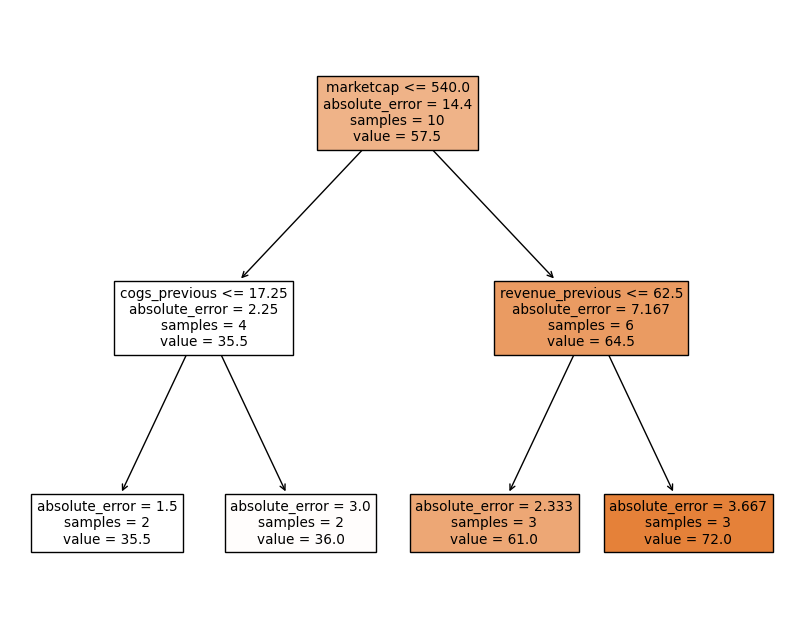

In [36]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn import tree
from sklearn.metrics import mean_absolute_error, mean_squared_error#, mean_absolute_percentage_error
from sklearn.tree import plot_tree
from matplotlib import pyplot as plt
import random

revenue = [random.randrange(25, 99) for i in range(11)]
dt_data = {
    "revenue": revenue,
    "revenue_previous": [(i+np.random.randint(-5,+5)) for i in revenue],
    "cogs_previous": [(i+np.random.randint(-5,+5))*0.5 for i in revenue],
    "marketcap": [(i+np.random.randint(-20,+20))*10 for i in revenue]
}

df_dt = pd.DataFrame(dt_data)

tree_params = {
    'criterion': 'absolute_error', 
    'max_depth': 3, 
    'min_samples_split': 2,
    'min_samples_leaf': 2,
    'max_features': None, 
    'max_leaf_nodes': None,
    }

tree = tree.DecisionTreeRegressor(**tree_params)
print(tree.get_params())

y = df_dt["revenue"]
X = df_dt.drop(columns="revenue")
indices = range(X.shape[0])
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(X, y, indices, test_size=0.05, shuffle=False)

# train the model
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

plt.figure(figsize=(10, 8))
plot_tree(tree, feature_names=X.columns.to_list(), filled=True)

In [53]:
pd.concat([X_train, y_train], axis=1)

,revenue_previous,cogs_previous,marketcap,revenue
0,65,36.0,860,68
1,34,15.0,200,34
2,60,30.0,720,61
3,39,19.5,310,39
4,32,17.0,500,37
5,54,25.5,680,54
6,75,38.5,930,79
7,59,31.5,580,61
8,76,34.0,780,72
9,34,17.5,430,33
